# 강원 영동/영서 날씨 차이 및 추가 지형·날씨 패턴 분석

## 분석 질문
1. 태백산맥 기준으로 만든 영동/영서 권역 간 날씨 차이가 통계적으로 보이는가?
2. 영동/영서 2분류 외에 고지·산간형 같은 제3 패턴이 존재하는가?
3. 군집이 단순 수치상 분리되는 것을 넘어, DEM 고도·위치·풍속·기온으로 지형적으로 설명 가능한가?

## 사용 데이터
- `data/강원도_날씨데이터/강원도날씨_격자.csv`
- `data/강원도_날씨데이터/강원도날씨_격자_일단위.csv`
- `data/강원도_데이터/강원도_공간데이터/강원도_DEM_데이터.tif`

분석 기간은 2020-01-01부터 2021-12-31까지 전체 기간이며, 11월~익년 5월은 산불 위험 계절 보조 검정으로 따로 확인한다.


## 해석 시 주의점

- 이 분석은 IDW 보간으로 만든 92개 기상셀의 2020~2021년 일단위 값이다. 날짜별 관측치는 서로 독립이라고 보기 어렵기 때문에, 결론은 셀 단위 평균 검정과 날짜별 paired 검정을 함께 보아 판단한다.
- 강수량은 0이 많고 극단값 영향이 크므로 Welch t-test보다 Mann-Whitney U와 날짜별 차이를 함께 본다.
- KMeans 군집은 탐색적 도구다. 따라서 지표가 조금 좋아졌다는 이유만으로 권역을 확정하지 않고, 고도·위치·기온·풍속이 동시에 설명될 때만 지형적 패턴으로 해석한다.


In [1]:
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.metrics import (
    adjusted_rand_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)
from sklearn.preprocessing import StandardScaler
import rasterio

try:
    from IPython.display import display
except Exception:
    display = print

font_path = "C:/Windows/Fonts/malgun.ttf"
if Path(font_path).exists():
    fm.fontManager.addfont(font_path)
    font_name = fm.FontProperties(fname=font_path).get_name()
else:
    font_name = "DejaVu Sans"

sns.set_theme(
    style="whitegrid",
    font=font_name,
    rc={
        "font.family": font_name,
        "font.sans-serif": [font_name],
        "axes.unicode_minus": False,
    },
)
plt.rcParams["font.family"] = font_name
plt.rcParams["font.sans-serif"] = [font_name]
plt.rcParams["axes.unicode_minus"] = False
pd.set_option("display.max_columns", None)

ROOT = Path.cwd()
for candidate in [ROOT, *ROOT.parents, Path("D:/farm-system-public-02")]:
    if (candidate / "data").exists() and (candidate / "jsw").exists():
        ROOT = candidate
        break

WEATHER_DIR = ROOT / "data" / "강원도_날씨데이터"
SPATIAL_DIR = ROOT / "data" / "강원도_데이터" / "강원도_공간데이터"
CELLS_PATH = WEATHER_DIR / "강원도날씨_격자.csv"
DAILY_PATH = WEATHER_DIR / "강원도날씨_격자_일단위.csv"
DEM_PATH = SPATIAL_DIR / "강원도_DEM_데이터.tif"

YEONGDONG = "영동"
YEONGSEO = "영서"
WEATHER_VARS = {
    "avg_temp": "평균기온_C",
    "min_temp": "최저기온_C",
    "max_temp": "최고기온_C",
    "precip": "강수량_mm",
    "max_gust": "최대순간풍속_m_s",
}

print("프로젝트 루트:", ROOT)
print("현재 matplotlib font.family:", plt.rcParams["font.family"])

프로젝트 루트: d:\farm-system-public-02
현재 matplotlib font.family: ['Malgun Gothic']


In [2]:
cells = pd.read_csv(CELLS_PATH, encoding="utf-8-sig").rename(
    columns={
        "기상셀ID": "cell_id",
        "기후권역": "region",
        "대표관측망": "station_network",
        "대표지점번호": "station_id",
        "대표지점명": "station_name",
        "면적_km2": "area_km2",
        "중심X_5186": "x5186",
        "중심Y_5186": "y5186",
        "중심경도_wgs84": "lon",
        "중심위도_wgs84": "lat",
    }
)

daily = pd.read_csv(DAILY_PATH, encoding="utf-8-sig").rename(
    columns={
        "기상셀ID": "cell_id",
        "날짜": "date",
        "평균기온_C": "avg_temp",
        "최저기온_C": "min_temp",
        "최고기온_C": "max_temp",
        "강수량_mm": "precip",
        "최대순간풍속_m_s": "max_gust",
        "최대순간풍향_deg": "gust_dir",
    }
)
daily["date"] = pd.to_datetime(daily["date"])

with rasterio.open(DEM_PATH) as src:
    coords = list(zip(cells["x5186"], cells["y5186"]))
    elev = np.array([value[0] for value in src.sample(coords)], dtype=float)
    elev[elev == src.nodata] = np.nan
cells["elev_m"] = elev

df = daily.merge(
    cells[["cell_id", "region", "station_network", "station_name", "area_km2", "x5186", "y5186", "lon", "lat", "elev_m"]],
    on="cell_id",
    how="left",
)
df["month"] = df["date"].dt.month
df["fire_season"] = df["month"].isin([11, 12, 1, 2, 3, 4, 5])
df["west_sector_gust"] = df["gust_dir"].between(225, 315, inclusive="both")
df["daily_temp_range"] = df["max_temp"] - df["min_temp"]

print("기상 셀:", cells.shape)
print("일단위 날씨:", daily.shape)
print("병합 후:", df.shape)
display(cells["region"].value_counts().rename_axis("기후권역").reset_index(name="셀수"))
display(df.head())

기상 셀: (92, 13)
일단위 날씨: (67252, 8)
병합 후: (67252, 21)


,기후권역,셀수
0,영서,71
1,영동,21


,cell_id,date,avg_temp,min_temp,max_temp,precip,max_gust,gust_dir,region,station_network,station_name,area_km2,x5186,y5186,lon,lat,elev_m,month,fire_season,west_sector_gust,daily_temp_range
0,YD_0001,2020-01-01,0.19,-3.47,5.28,0.0,13.13,221.77,영동,ASOS,강릉,134.467293,367778.425131,569785.112496,128.902714,37.712422,38.398575,1,True,False,8.75
1,YD_0002,2020-01-01,-1.68,-3.73,2.25,0.0,14.52,267.30,영동,ASOS,속초,102.982315,331807.869122,630148.837915,128.506006,38.261948,61.493595,1,True,True,5.98
2,YD_0003,2020-01-01,2.01,-2.04,6.53,0.0,14.21,309.54,영동,ASOS,동해,60.417467,385679.625075,547421.764901,129.099934,37.507617,81.152412,1,True,True,8.57
3,YD_0004,2020-01-01,-0.31,-2.31,4.74,0.0,10.12,325.57,영동,AWS,강현,39.694215,338601.941682,615714.148931,128.580793,38.130934,45.542442,1,True,False,7.05
4,YD_0005,2020-01-01,-1.31,-3.16,2.30,0.0,15.33,249.37,영동,AWS,간성,177.032843,325342.618059,640768.390574,128.434040,38.358513,79.080040,1,True,True,5.46


## 1. 영동/영서 기본 구조

먼저 DEM 고도와 일단위 날씨 요약으로 기존 영동/영서 구분이 어떤 지형·날씨 차이를 갖는지 확인한다.

In [3]:
def cohen_d(a, b):
    a = pd.Series(a).dropna()
    b = pd.Series(b).dropna()
    if len(a) < 2 or len(b) < 2:
        return np.nan
    pooled = np.sqrt(((len(a) - 1) * a.var(ddof=1) + (len(b) - 1) * b.var(ddof=1)) / (len(a) + len(b) - 2))
    return (a.mean() - b.mean()) / pooled if pooled else np.nan

def bh_fdr(p_values):
    p = np.asarray(p_values, dtype=float)
    n = len(p)
    order = np.argsort(p)
    adjusted = np.empty(n, dtype=float)
    prev = 1.0
    for rank, idx in enumerate(order[::-1], start=1):
        original_rank = n - rank + 1
        val = min(prev, p[idx] * n / original_rank)
        adjusted[idx] = val
        prev = val
    return adjusted

def make_region_tests(work, subset_label):
    cell_mean = work.groupby(["cell_id", "region"], as_index=False)[list(WEATHER_VARS.keys())].mean()
    rows = []
    for var, label in WEATHER_VARS.items():
        yd = cell_mean.loc[cell_mean["region"] == YEONGDONG, var].dropna()
        ys = cell_mean.loc[cell_mean["region"] == YEONGSEO, var].dropna()
        welch = stats.ttest_ind(yd, ys, equal_var=False)
        mw = stats.mannwhitneyu(yd, ys, alternative="two-sided")
        rows.append(
            {
                "분석범위": subset_label,
                "변수": label,
                "영동_N셀": len(yd),
                "영서_N셀": len(ys),
                "영동_평균": yd.mean(),
                "영서_평균": ys.mean(),
                "영동-영서": yd.mean() - ys.mean(),
                "Welch_t": welch.statistic,
                "Welch_p": welch.pvalue,
                "MannWhitney_p": mw.pvalue,
                "Cohen_d": cohen_d(yd, ys),
            }
        )
    cell_tests = pd.DataFrame(rows)
    cell_tests["Welch_p_FDR"] = bh_fdr(cell_tests["Welch_p"])

    reg_day = work.groupby(["date", "region"], as_index=False)[list(WEATHER_VARS.keys())].mean()
    pivot = reg_day.pivot(index="date", columns="region", values=list(WEATHER_VARS.keys()))
    rows = []
    for var, label in WEATHER_VARS.items():
        diff = (pivot[(var, YEONGDONG)] - pivot[(var, YEONGSEO)]).dropna()
        paired = stats.ttest_1samp(diff, 0.0)
        try:
            wilcoxon_p = stats.wilcoxon(diff).pvalue
        except Exception:
            wilcoxon_p = np.nan
        rows.append(
            {
                "분석범위": subset_label,
                "변수": label,
                "날짜수": len(diff),
                "평균_차이(영동-영서)": diff.mean(),
                "차이_중앙값": diff.median(),
                "paired_t_p": paired.pvalue,
                "wilcoxon_p": wilcoxon_p,
            }
        )
    paired_tests = pd.DataFrame(rows)
    paired_tests["paired_t_p_FDR"] = bh_fdr(paired_tests["paired_t_p"])

    west_cell = work.groupby(["cell_id", "region"], as_index=False)["west_sector_gust"].mean()
    yd = west_cell.loc[west_cell["region"] == YEONGDONG, "west_sector_gust"].dropna()
    ys = west_cell.loc[west_cell["region"] == YEONGSEO, "west_sector_gust"].dropna()
    west = pd.DataFrame(
        [{
            "분석범위": subset_label,
            "변수": "최대순간풍향_서풍계열비율(225~315도)",
            "영동_N셀": len(yd),
            "영서_N셀": len(ys),
            "영동_평균": yd.mean(),
            "영서_평균": ys.mean(),
            "영동-영서": yd.mean() - ys.mean(),
            "Welch_p": stats.ttest_ind(yd, ys, equal_var=False).pvalue,
            "MannWhitney_p": stats.mannwhitneyu(yd, ys, alternative="two-sided").pvalue,
            "Cohen_d": cohen_d(yd, ys),
        }]
    )
    return cell_tests, paired_tests, west

def format_result_table(table):
    out = table.copy()
    p_cols = [col for col in out.columns if col.endswith("_p") or col.endswith("_p_FDR") or col in ["Welch_p", "MannWhitney_p"]]
    for col in out.select_dtypes(include=[np.number]).columns:
        if col in p_cols:
            out[col] = out[col].map(lambda x: f"{x:.2e}" if pd.notna(x) and x < 0.001 else (f"{x:.4f}" if pd.notna(x) else ""))
        elif "N" in col or col in ["날짜수", "셀수"]:
            out[col] = out[col].astype("Int64")
        else:
            out[col] = out[col].map(lambda x: f"{x:.3f}" if pd.notna(x) else "")
    return out

In [4]:
print("DEM 고도 요약")
display(cells.groupby("region")["elev_m"].describe().round(2))

weather_summary = (
    df.groupby("region")[list(WEATHER_VARS.keys()) + ["daily_temp_range"]]
    .agg(["count", "mean", "std", "median"])
    .round(3)
)
display(weather_summary)

DEM 고도 요약


,count,mean,std,min,25%,50%,75%,max
region,,,,,,,,
영동,21.0,129.33,100.72,2.55,61.49,91.38,148.89,371.79
영서,71.0,502.15,272.24,59.99,253.95,468.40,696.86,1197.04


avg_temp                       min_temp                       max_temp  \
          count    mean    std median    count   mean     std median    count   
region                                                                          
영동        15351  12.351  8.475  12.40    15351  7.890   9.043   7.22    15351   
영서        51901   9.899  9.879   9.71    51901  4.729  10.550   3.57    51901   

                             precip                       max_gust         \
          mean    std median  count   mean     std median    count   mean   
region                                                                      
영동      17.146  8.368  17.88  15351  4.502  17.233    0.0    15351  8.951   
영서      16.027  9.933  16.95  51901  3.827  13.671    0.0    51901  7.963   

                     daily_temp_range                        
          std median            count    mean    std median  
region                                                       
영동      3.324   8.26            15351   9.256  3.171   9.34  
영서      3.441   7.18            51901  11.298  4.299  11.13

In [5]:
all_cell_tests, all_paired_tests, all_west = make_region_tests(df, "전체기간")
fire_cell_tests, fire_paired_tests, fire_west = make_region_tests(df.loc[df["fire_season"]].copy(), "산불위험계절(11~5월)")

print("셀 단위 평균 비교: Welch t-test + Mann-Whitney U")
display(format_result_table(all_cell_tests))

print("날짜별 권역 평균 차이: paired t-test + Wilcoxon")
display(format_result_table(all_paired_tests))

print("산불 위험 계절(11~5월) 셀 단위 평균 비교")
display(format_result_table(fire_cell_tests))

print("풍향 보조 분석: 최대순간풍향 225~315도 비율")
display(format_result_table(pd.concat([all_west, fire_west], ignore_index=True)))

셀 단위 평균 비교: Welch t-test + Mann-Whitney U


,분석범위,변수,영동_N셀,영서_N셀,영동_평균,영서_평균,영동-영서,Welch_t,Welch_p,MannWhitney_p,Cohen_d,Welch_p_FDR
0,전체기간,평균기온_C,21,71,12.351,9.899,2.452,8.794,1.88e-12,7.35e-10,1.618,4.69e-12
1,전체기간,최저기온_C,21,71,7.890,4.729,3.161,10.762,9.05e-14,1.75e-10,2.295,4.53e-13
2,전체기간,최고기온_C,21,71,17.146,16.027,1.119,3.359,0.0012,0.0200,0.557,0.0015
3,전체기간,강수량_mm,21,71,4.502,3.827,0.676,2.641,0.0128,9.34e-05,0.679,0.0128
4,전체기간,최대순간풍속_m_s,21,71,8.951,7.963,0.988,3.599,5.77e-04,4.53e-04,0.618,9.62e-04


날짜별 권역 평균 차이: paired t-test + Wilcoxon


,분석범위,변수,날짜수,평균_차이(영동-영서),차이_중앙값,paired_t_p,wilcoxon_p,paired_t_p_FDR
0,전체기간,평균기온_C,731,2.452,2.575,3.11e-144,5.10e-99,7.77e-144
1,전체기간,최저기온_C,731,3.161,3.105,5.52e-199,6.84e-119,2.76e-198
2,전체기간,최고기온_C,731,1.119,1.411,1.38e-27,4.69e-26,1.72e-27
3,전체기간,강수량_mm,731,0.676,0.000,0.0766,0.1162,0.0766
4,전체기간,최대순간풍속_m_s,731,0.988,0.974,2.65e-70,5.13e-63,4.42e-70


산불 위험 계절(11~5월) 셀 단위 평균 비교


,분석범위,변수,영동_N셀,영서_N셀,영동_평균,영서_평균,영동-영서,Welch_t,Welch_p,MannWhitney_p,Cohen_d,Welch_p_FDR
0,산불위험계절(11~5월),평균기온_C,21,71,7.062,3.802,3.260,14.065,6.84e-19,9.17e-12,2.818,1.71e-18
1,산불위험계절(11~5월),최저기온_C,21,71,2.078,-1.969,4.047,16.619,3.16e-21,9.17e-12,3.411,1.58e-20
2,산불위험계절(11~5월),최고기온_C,21,71,12.162,10.232,1.930,6.570,9.85e-09,1.09e-06,1.180,1.64e-08
3,산불위험계절(11~5월),강수량_mm,21,71,1.952,1.859,0.093,0.922,0.3644,0.1992,0.256,0.3644
4,산불위험계절(11~5월),최대순간풍속_m_s,21,71,9.916,8.596,1.320,4.239,5.94e-05,1.65e-04,0.699,7.43e-05


풍향 보조 분석: 최대순간풍향 225~315도 비율


,분석범위,변수,영동_N셀,영서_N셀,영동_평균,영서_평균,영동-영서,Welch_p,MannWhitney_p,Cohen_d
0,전체기간,최대순간풍향_서풍계열비율(225~315도),21,71,0.384,0.364,0.020,0.5759,0.7659,0.109
1,산불위험계절(11~5월),최대순간풍향_서풍계열비율(225~315도),21,71,0.480,0.424,0.056,0.1838,0.3403,0.257


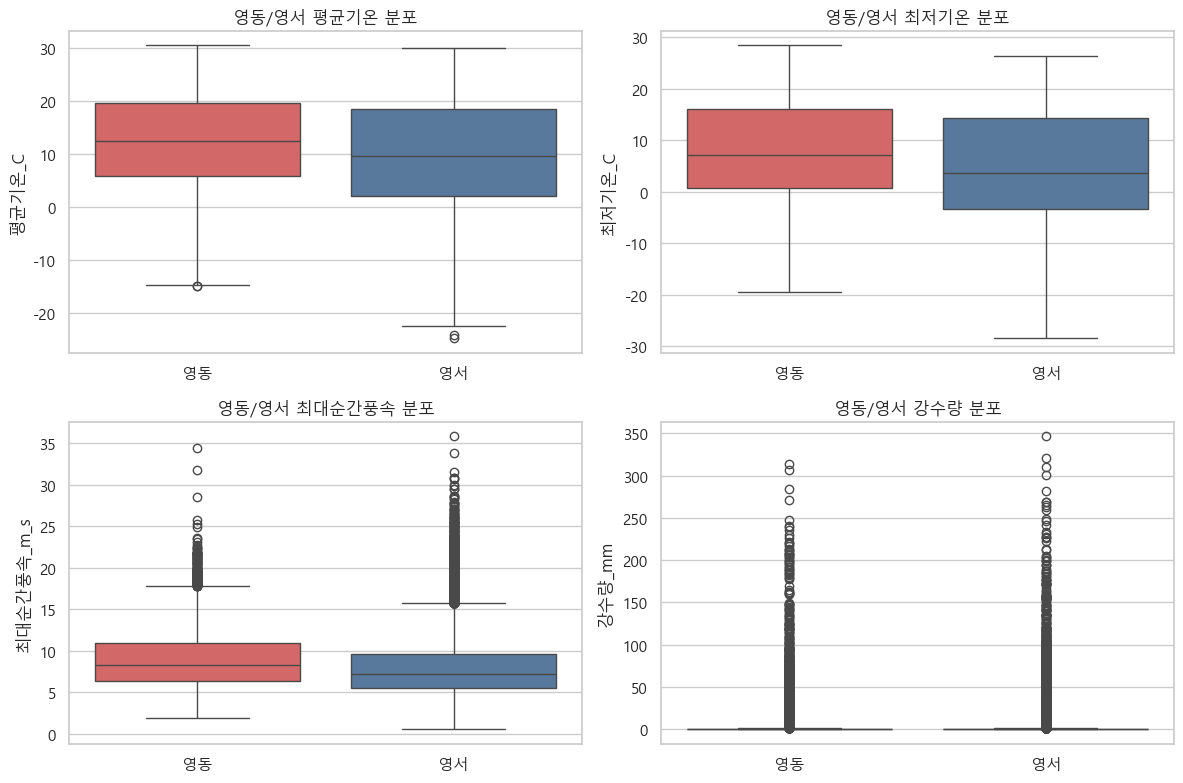

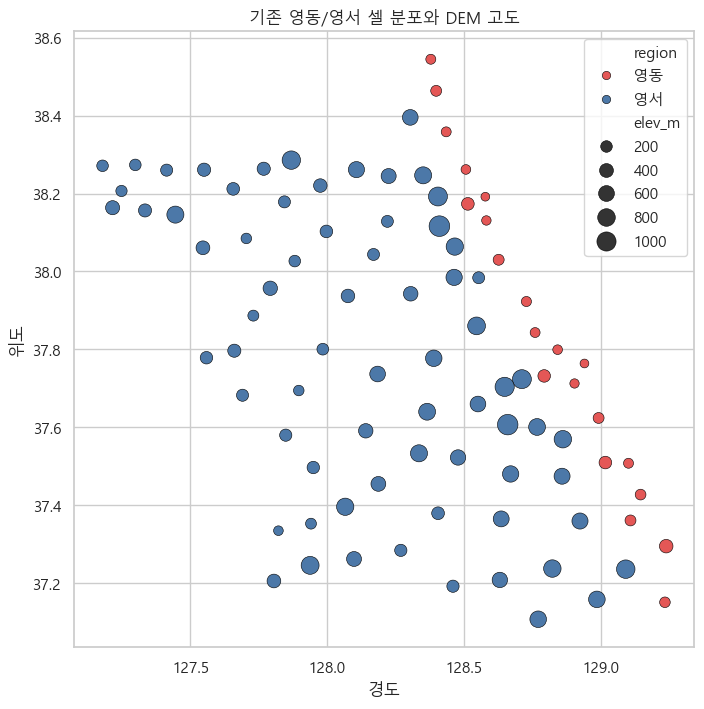

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, var, title in zip(
    axes.ravel(),
    ["avg_temp", "min_temp", "max_gust", "precip"],
    ["평균기온", "최저기온", "최대순간풍속", "강수량"],
):
    sns.boxplot(
        data=df,
        x="region",
        y=var,
        hue="region",
        ax=ax,
        palette={"영동": "#E45756", "영서": "#4C78A8"},
        legend=False,
    )
    ax.set_title(f"영동/영서 {title} 분포")
    ax.set_xlabel("")
    ax.set_ylabel(WEATHER_VARS.get(var, var))
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 8))
sns.scatterplot(
    data=cells,
    x="lon",
    y="lat",
    hue="region",
    size="elev_m",
    sizes=(40, 220),
    palette={"영동": "#E45756", "영서": "#4C78A8"},
    edgecolor="black",
    linewidth=0.4,
    ax=ax,
)
ax.set_title("기존 영동/영서 셀 분포와 DEM 고도")
ax.set_xlabel("경도")
ax.set_ylabel("위도")
plt.show()

## 2. 영동/영서 외 추가 패턴 탐색

군집은 `날씨만`, `날씨+DEM`, `날씨+DEM+위치` 세 가지 입력으로 비교한다. 위치 포함 군집은 지역권 분류, 위치 제외 군집은 지형·날씨 유형 분류로 해석한다.

In [7]:
def build_cluster_features(cells, df):
    agg = (
        df.groupby("cell_id")
        .agg(
            avg_temp_mean=("avg_temp", "mean"),
            avg_temp_std=("avg_temp", "std"),
            min_temp_mean=("min_temp", "mean"),
            max_temp_mean=("max_temp", "mean"),
            temp_range_mean=("daily_temp_range", "mean"),
            precip_mean=("precip", "mean"),
            precip_sum=("precip", "sum"),
            max_gust_mean=("max_gust", "mean"),
            max_gust_q90=("max_gust", lambda s: s.quantile(0.90)),
            west_sector_rate=("west_sector_gust", "mean"),
        )
        .reset_index()
    )
    return cells[["cell_id", "region", "station_name", "lon", "lat", "elev_m"]].merge(agg, on="cell_id", how="left")

def zscore(s):
    std = s.std(ddof=0)
    return (s - s.mean()) / std if std else s * 0

def assign_cluster_labels(tmp, k, regional):
    profile = (
        tmp.groupby("cluster")
        .agg(
            lon=("lon", "mean"),
            lat=("lat", "mean"),
            elev_m=("elev_m", "mean"),
            avg_temp_mean=("avg_temp_mean", "mean"),
            max_gust_mean=("max_gust_mean", "mean"),
            west_sector_rate=("west_sector_rate", "mean"),
            n=("cell_id", "size"),
        )
        .copy()
    )
    labels = {}
    if k == 3:
        mountain_score = zscore(profile["elev_m"]) - zscore(profile["avg_temp_mean"]) + zscore(profile["max_gust_mean"])
        mountain_cluster = int(mountain_score.idxmax())
        labels[mountain_cluster] = "고지·산간형"
        remaining = [idx for idx in profile.index if idx != mountain_cluster]
        coast_score = zscore(profile.loc[remaining, "lon"]) - zscore(profile.loc[remaining, "elev_m"]) + zscore(profile.loc[remaining, "avg_temp_mean"])
        coast_cluster = int(coast_score.idxmax())
        labels[coast_cluster] = "영동 해안형" if regional else "저고도·온난형"
        for idx in profile.index:
            labels.setdefault(int(idx), "영서 내륙형" if regional else "중간고도·내륙형")
    else:
        east_score = zscore(profile["lon"]) - zscore(profile["elev_m"]) + zscore(profile["avg_temp_mean"])
        east_cluster = int(east_score.idxmax())
        for idx in profile.index:
            labels[int(idx)] = "영동·저고도형" if int(idx) == east_cluster else "영서·고지내륙형"
    return tmp["cluster"].map(labels)

def run_cluster_analysis(features):
    feature_sets = {
        "날씨만": [
            "avg_temp_mean", "avg_temp_std", "min_temp_mean", "max_temp_mean",
            "temp_range_mean", "precip_mean", "max_gust_mean", "max_gust_q90", "west_sector_rate",
        ],
        "날씨+DEM": [
            "elev_m", "avg_temp_mean", "avg_temp_std", "min_temp_mean", "max_temp_mean",
            "temp_range_mean", "precip_mean", "max_gust_mean", "max_gust_q90", "west_sector_rate",
        ],
        "날씨+DEM+위치": [
            "lon", "lat", "elev_m", "avg_temp_mean", "avg_temp_std", "min_temp_mean", "max_temp_mean",
            "temp_range_mean", "precip_mean", "max_gust_mean", "max_gust_q90", "west_sector_rate",
        ],
    }
    metrics = []
    labeled = {}
    truth = (features["region"] == YEONGDONG).astype(int).to_numpy()
    for set_name, cols in feature_sets.items():
        X = features[cols].copy()
        X = X.fillna(X.median(numeric_only=True))
        Xs = StandardScaler().fit_transform(X)
        for k in [2, 3]:
            labels = KMeans(n_clusters=k, random_state=42, n_init=100).fit_predict(Xs)
            key = f"{set_name}_K{k}"
            tmp = features.copy()
            tmp["cluster"] = labels
            tmp["cluster_label"] = assign_cluster_labels(tmp, k=k, regional=("위치" in set_name))
            labeled[key] = tmp
            metrics.append(
                {
                    "feature_set": set_name,
                    "K": k,
                    "silhouette": silhouette_score(Xs, labels),
                    "calinski_harabasz": calinski_harabasz_score(Xs, labels),
                    "davies_bouldin": davies_bouldin_score(Xs, labels),
                    "ARI_vs_영동영서": adjusted_rand_score(truth, labels) if k == 2 else np.nan,
                }
            )
    return pd.DataFrame(metrics), labeled

features = build_cluster_features(cells, df)
cluster_metrics, labeled = run_cluster_analysis(features)
display(cluster_metrics.round(4))

,feature_set,K,silhouette,calinski_harabasz,davies_bouldin,ARI_vs_영동영서
0,날씨만,2,0.3173,33.9152,1.3941,0.2883
1,날씨만,3,0.3327,40.3197,0.9353,NaN
2,날씨+DEM,2,0.3165,29.7093,1.5048,-0.0415
3,날씨+DEM,3,0.3566,36.7123,1.1440,NaN
4,날씨+DEM+위치,2,0.2635,27.6215,1.6260,0.3118
5,날씨+DEM+위치,3,0.3134,31.0521,1.3126,NaN


In [8]:
for key in ["날씨+DEM_K3", "날씨+DEM+위치_K3"]:
    print(f"\n=== {key} ===")
    tmp = labeled[key]
    display(pd.crosstab(tmp["cluster_label"], tmp["region"]))
    profile = (
        tmp.groupby("cluster_label")
        .agg(
            셀수=("cell_id", "size"),
            평균고도_m=("elev_m", "mean"),
            평균위도=("lat", "mean"),
            평균경도=("lon", "mean"),
            평균기온_C=("avg_temp_mean", "mean"),
            평균_최대순간풍속_m_s=("max_gust_mean", "mean"),
            서풍계열비율=("west_sector_rate", "mean"),
        )
        .round(3)
    )
    display(profile)
    station_list = (
        tmp.sort_values(["cluster_label", "lat", "lon"])
        .groupby("cluster_label")["station_name"]
        .apply(lambda x: ", ".join(x.astype(str).head(20).tolist()))
        .rename("대표 지점 목록")
    )
    display(station_list)


=== 날씨+DEM_K3 ===


region,영동,영서
cluster_label,,
고지·산간형,1,18
저고도·온난형,20,1
중간고도·내륙형,0,52


,셀수,평균고도_m,평균위도,평균경도,평균기온_C,평균_최대순간풍속_m_s,서풍계열비율
cluster_label,,,,,,,
고지·산간형,19,786.864,37.842,128.413,8.383,10.024,0.476
저고도·온난형,21,126.664,37.870,128.778,12.404,8.959,0.355
중간고도·내륙형,52,399.191,37.753,128.051,10.432,7.207,0.335


cluster_label
고지·산간형      도계, 사북, 원주백운산, 달방댐, 시동, 강릉왕산, 평창용산, 스키점프, 대관령,...
저고도·온난형     원덕, 궁촌, 신기, 삼척, 동해, 옥계, 강릉, 강릉성산, 경포, 북강릉, 연곡,...
중간고도·내륙형    상동, 태백, 영월, 부론, 신동, 신림, 영월주천, 문막, 원주, 하장, 정선군,...
Name: 대표 지점 목록, dtype: str


=== 날씨+DEM+위치_K3 ===


region,영동,영서
cluster_label,,
고지·산간형,1,21
영동 해안형,20,1
영서 내륙형,0,49


,셀수,평균고도_m,평균위도,평균경도,평균기온_C,평균_최대순간풍속_m_s,서풍계열비율
cluster_label,,,,,,,
고지·산간형,22,776.564,37.782,128.471,8.546,9.824,0.443
영동 해안형,21,126.664,37.870,128.778,12.404,8.959,0.355
영서 내륙형,49,380.080,37.775,128.003,10.484,7.125,0.342


cluster_label
고지·산간형    태백, 도계, 사북, 원주백운산, 북평, 달방댐, 삽당령, 시동, 강릉왕산, 평창용...
영동 해안형    원덕, 궁촌, 신기, 삼척, 동해, 옥계, 강릉, 강릉성산, 경포, 북강릉, 연곡,...
영서 내륙형    상동, 영월, 부론, 신동, 신림, 영월주천, 문막, 원주, 하장, 정선군, 평창,...
Name: 대표 지점 목록, dtype: str

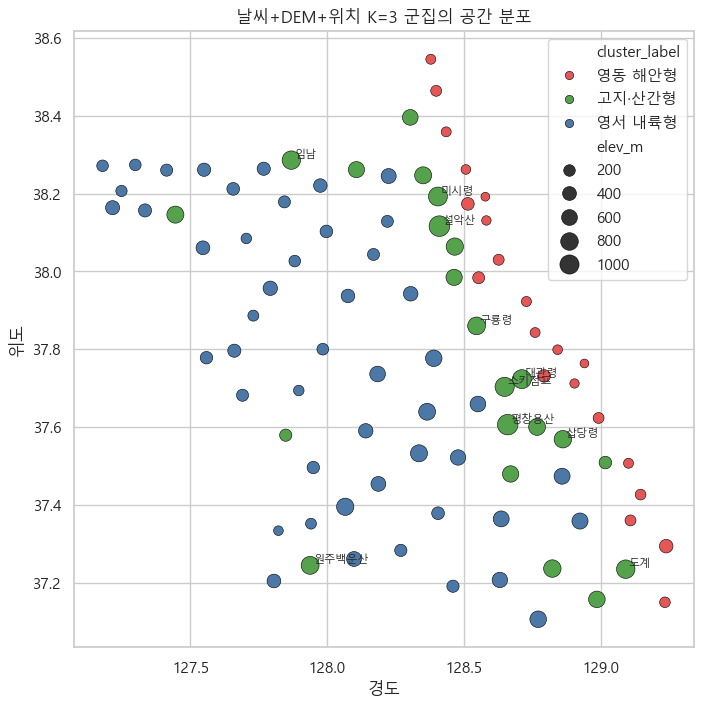

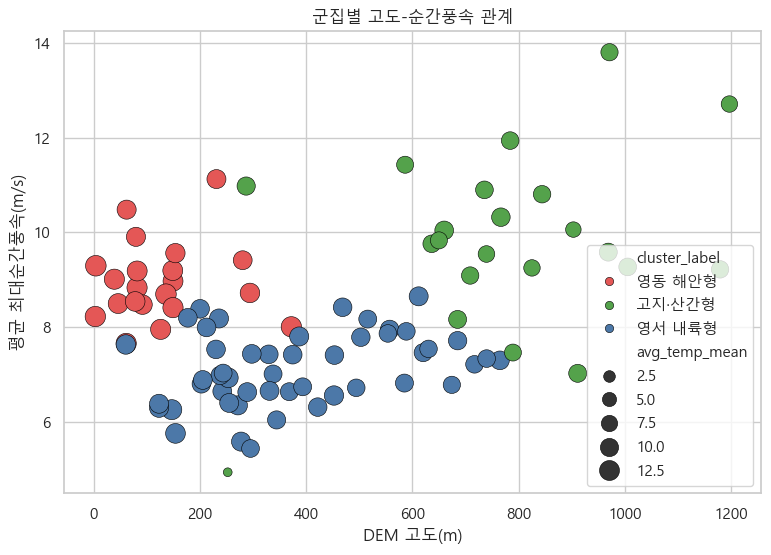

In [9]:
regional_k3 = labeled["날씨+DEM+위치_K3"].copy()
palette = {"영동 해안형": "#E45756", "영서 내륙형": "#4C78A8", "고지·산간형": "#54A24B"}

fig, ax = plt.subplots(figsize=(8, 8))
sns.scatterplot(
    data=regional_k3,
    x="lon",
    y="lat",
    hue="cluster_label",
    size="elev_m",
    sizes=(40, 220),
    palette=palette,
    edgecolor="black",
    linewidth=0.4,
    ax=ax,
)
for _, row in regional_k3.iterrows():
    if row["elev_m"] >= regional_k3["elev_m"].quantile(0.90):
        ax.text(row["lon"] + 0.01, row["lat"] + 0.005, row["station_name"], fontsize=8)
ax.set_title("날씨+DEM+위치 K=3 군집의 공간 분포")
ax.set_xlabel("경도")
ax.set_ylabel("위도")
plt.show()

fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(
    data=regional_k3,
    x="elev_m",
    y="max_gust_mean",
    hue="cluster_label",
    size="avg_temp_mean",
    sizes=(40, 220),
    palette=palette,
    edgecolor="black",
    linewidth=0.4,
    ax=ax,
)
ax.set_title("군집별 고도-순간풍속 관계")
ax.set_xlabel("DEM 고도(m)")
ax.set_ylabel("평균 최대순간풍속(m/s)")
plt.show()

## 최종 해석

1. **영동/영서 차이는 통계적으로 확인된다.** 셀 단위 평균 기준으로 영동은 영서보다 평균기온이 2.45℃ 높고(Welch p=1.88e-12, d=1.62), 최저기온은 3.16℃ 높다(Welch p=9.05e-14, d=2.30). 최대순간풍속도 영동이 0.99m/s 높다(Welch p=5.77e-04, d=0.62). 날짜별 권역 평균 차이 검정에서도 기온과 최대순간풍속 차이는 매우 안정적으로 유지된다.

2. **강수량 차이는 방향은 영동이 높지만 해석 강도는 기온·풍속보다 낮다.** 셀 단위 평균에서는 영동이 0.68mm 높게 나오지만(Welch p=0.0128), 날짜별 paired test에서는 강수의 일별 변동성이 커서 다른 변수보다 약하게 나타난다.

3. **풍향은 서풍계열 비율만으로는 영동/영서를 강하게 가르지 못한다.** 최대순간풍향 225~315도 비율은 영동 0.384, 영서 0.364이며 Welch p=0.5759이다. 즉 이 자료에서는 풍향 자체보다 풍속·기온·고도의 결합이 더 분명한 차이를 만든다.

4. **2분류만으로는 일부 고지·산간 패턴이 묻힌다.** 위치를 포함한 `날씨+DEM+위치` 군집에서 K=3의 silhouette=0.313, Davies-Bouldin=1.313로 K=2(silhouette=0.264)보다 나아진다. `날씨+DEM`만으로도 K=3이 산간형 후보를 만든다(silhouette=0.357). 따라서 결론은 “영동/영서가 주된 1차 구조이고, 그 안팎에 고지·산간형이 보조적인 제3 패턴으로 존재한다”가 가장 안전하다.

5. **제3 패턴은 행정권역보다 지형 유형에 가깝다.** 고지·산간형은 서로 완전히 붙어 있는 하나의 행정권역이라기보다, 대관령·미시령·설악산·평창 고지대처럼 고도가 높고 기온이 낮으며 순간풍속이 강한 셀들이 묶인 유형이다. 따라서 소백산맥/태백산맥 같은 산지 축의 영향을 탐색하는 근거로는 유효하지만, 별도 권역 경계선을 확정하려면 산맥 경계선 또는 능선축을 명시적으로 만든 후 추가 검정하는 것이 맞다.

## 3. 지형 연속성과 전이 셀을 반영한 3권역 재분류

기존 군집분석은 “비슷한 날씨·고도 특성”을 찾는 데는 유용하지만, 떨어진 고지 셀까지 같은 유형으로 묶을 수 있다. 따라서 최종 산출용 분류는 군집 결과를 그대로 쓰지 않고 다음 규칙으로 만든다.

- 기존 `영동`은 모두 `영동 해안형`으로 유지한다.
- 기존 `영서` 중 동쪽 고고도 산지 seed를 잡고, seed 사이를 영서 셀 인접 그래프에서 고도와 동쪽 위치를 선호하는 최단 경로로 연결한다.
- 연결 산지축 주변에서 일정 고도 이상인 셀을 확장 포함한다.
- 조침령 오른쪽처럼 산지축과 기존 영동 사이에 끼는 동쪽 전이 셀은, 산지축과 영동 양쪽에 접하고 최대순간풍속이 높은 경우 `고지·산간형`에 포함한다.
- 최종 CSV는 다른 분석에서 병합하기 쉽도록 `기상셀ID`, `기후권역`, `기후지형유형` 세 컬럼만 `data/강원도_날씨데이터`에 저장한다.
- 지도 시각화 PNG도 `data/강원도_날씨데이터`에 저장하고, 별도 GeoJSON 산출물은 만들지 않는다.


In [10]:
from collections import defaultdict, deque
import heapq
import geopandas as gpd

terrain_out_csv = WEATHER_DIR / "강원도날씨_기후지형유형_셀분류.csv"
terrain_out_png = WEATHER_DIR / "강원도날씨_기후지형유형_시각화.png"

def _build_adjacency(gdf_5186, allowed):
    allowed = set(allowed)
    geoms = {idx: gdf_5186.loc[idx, "geometry"].buffer(0.5) for idx in allowed}
    adj = {idx: set() for idx in allowed}
    idxs = list(allowed)
    for pos, i in enumerate(idxs):
        for j in idxs[pos + 1:]:
            if geoms[i].intersects(geoms[j]):
                adj[i].add(j)
                adj[j].add(i)
    return adj

def _components(nodes, adj):
    nodes = set(nodes)
    visited, out = set(), []
    for node in nodes:
        if node in visited:
            continue
        q, comp = deque([node]), []
        visited.add(node)
        while q:
            cur = q.popleft()
            comp.append(cur)
            for nxt in adj.get(cur, set()):
                if nxt in nodes and nxt not in visited:
                    visited.add(nxt)
                    q.append(nxt)
        out.append(comp)
    return sorted(out, key=len, reverse=True)

def _shortest_path_between(sources, targets, adj, gdf):
    dist = {node: float("inf") for node in adj}
    prev, heap = {}, []
    for src in sources:
        dist[src] = 0
        heapq.heappush(heap, (0, src))
    hit = None
    while heap:
        cost, cur = heapq.heappop(heap)
        if cost > dist[cur]:
            continue
        if cur in targets:
            hit = cur
            break
        for nxt in adj[cur]:
            row = gdf.loc[nxt]
            step = max(1.8 - 0.55 * min(row["elev_m"] / 900, 1.2) - 0.35 * max((row["lon"] - 128.0) / 0.9, 0), 0.35)
            if cost + step < dist[nxt]:
                dist[nxt], prev[nxt] = cost + step, cur
                heapq.heappush(heap, (cost + step, nxt))
    if hit is None:
        return []
    path = [hit]
    cur = hit
    while cur not in sources:
        cur = prev[cur]
        path.append(cur)
    return list(reversed(path))

def build_continuous_climate_terrain_outputs():
    base_gdf = gpd.read_file(WEATHER_DIR / "강원도날씨_격자.geojson").rename(columns={"기상셀ID": "cell_id"})
    feature_table = cells[["cell_id", "region", "station_name", "lon", "lat", "x5186", "y5186", "elev_m"]].merge(
        df.groupby("cell_id").agg(
            avg_temp_mean=("avg_temp", "mean"),
            min_temp_mean=("min_temp", "mean"),
            max_temp_mean=("max_temp", "mean"),
            temp_range_mean=("daily_temp_range", "mean"),
            precip_mean=("precip", "mean"),
            max_gust_mean=("max_gust", "mean"),
            max_gust_q90=("max_gust", lambda s: s.quantile(0.90)),
            west_sector_rate=("west_sector_gust", "mean"),
        ).reset_index(),
        on="cell_id",
        how="left",
    )
    terrain_gdf = base_gdf.merge(feature_table, on="cell_id", how="left", suffixes=("", "_feature"))
    terrain_5186 = terrain_gdf.to_crs("EPSG:5186")
    all_adj = _build_adjacency(terrain_5186, set(terrain_gdf.index))
    ys_idx = set(terrain_gdf.index[terrain_gdf["region"] == "영서"])
    yd_idx = set(terrain_gdf.index[terrain_gdf["region"] == "영동"])
    ys_adj = {idx: all_adj[idx] & ys_idx for idx in ys_idx}
    seed_idx = set(
        terrain_gdf.index[
            (terrain_gdf["region"] == "영서")
            & (terrain_gdf["lon"] >= 128.20)
            & (terrain_gdf["elev_m"] >= 600)
            & (terrain_gdf["max_gust_mean"] >= 7.0)
        ]
    )
    seed_components = _components(seed_idx, ys_adj)
    axis = set(seed_components[0])
    for comp in seed_components[1:]:
        axis.update(_shortest_path_between(axis, set(comp), ys_adj, terrain_gdf))
        axis.update(comp)
    changed = True
    while changed:
        changed = False
        for node in list(axis):
            for nxt in ys_adj[node]:
                if nxt in axis:
                    continue
                row = terrain_gdf.loc[nxt]
                if (row["lon"] >= 128.30 and row["elev_m"] >= 500) or (row["lon"] >= 128.45 and row["elev_m"] >= 430):
                    axis.add(nxt)
                    changed = True
    changed = True
    while changed:
        changed = False
        for idx in sorted(ys_idx - axis):
            row = terrain_gdf.loc[idx]
            if (all_adj[idx] & axis) and (all_adj[idx] & yd_idx) and row["lon"] >= 128.45 and row["max_gust_mean"] >= 8.0:
                axis.add(idx)
                changed = True
    terrain_gdf["climate_terrain_type"] = np.where(terrain_gdf["region"] == "영동", "영동 해안형", "영서 내륙형")
    terrain_gdf.loc[list(axis), "climate_terrain_type"] = "고지·산간형"
    terrain_gdf.loc[terrain_gdf["region"] == "영동", "climate_terrain_type"] = "영동 해안형"

    mapping = pd.DataFrame(
        {
            "기상셀ID": terrain_gdf["cell_id"],
            "기후권역": terrain_gdf["region"],
            "기후지형유형": terrain_gdf["climate_terrain_type"],
        }
    )
    mapping.to_csv(terrain_out_csv, index=False, encoding="utf-8-sig")
    return mapping, terrain_gdf

terrain_mapping, terrain_gdf = build_continuous_climate_terrain_outputs()
display(pd.crosstab(terrain_mapping["기후권역"], terrain_mapping["기후지형유형"]))
display(terrain_mapping.head())

기후지형유형,고지·산간형,영동 해안형,영서 내륙형
기후권역,,,
영동,0,21,0
영서,27,0,44


,기상셀ID,기후권역,기후지형유형
0,YD_0001,영동,영동 해안형
1,YD_0002,영동,영동 해안형
2,YD_0003,영동,영동 해안형
3,YD_0004,영동,영동 해안형
4,YD_0005,영동,영동 해안형


,셀수,평균고도_m,평균기온_C,최저기온_C,일교차_C,평균_최대순간풍속_m_s,최대순간풍속_90p_m_s,서풍계열비율,강수량_일평균_mm
climate_terrain_type,,,,,,,,,
고지·산간형,27,741.868,9.364,4.518,10.514,9.169,13.874,0.375,4.206
영동 해안형,21,129.329,12.351,7.890,9.256,8.951,13.360,0.384,4.502
영서 내륙형,44,355.044,10.228,4.858,11.779,7.223,10.730,0.358,3.594


,변수,ANOVA_F,ANOVA_p,Kruskal_H,Kruskal_p
0,평균기온_C,25.17762,0.00000,48.75994,0.00000
1,최저기온_C,43.21223,0.00000,43.36496,0.00000
2,최고기온_C,8.83022,0.00032,29.62337,0.00000
3,일교차_C,30.28504,0.00000,37.13496,0.00000
4,강수량_mm,7.35504,0.00111,17.30061,0.00018
5,최대순간풍속_m_s,21.12720,0.00000,35.26499,0.00000
6,서풍계열_최대순간풍향_비율,0.16835,0.84533,0.22796,0.89227


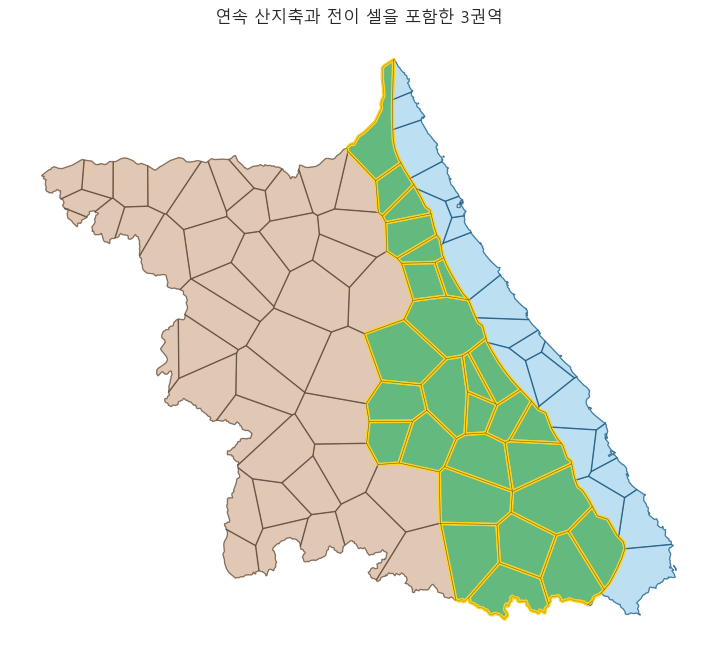

In [11]:
three_df = daily.merge(terrain_mapping.rename(columns={"기상셀ID": "cell_id", "기후지형유형": "climate_terrain_type"})[["cell_id", "climate_terrain_type"]], on="cell_id", how="left")
three_df["west_sector_gust"] = three_df["gust_dir"].between(225, 315, inclusive="both")
three_df["daily_temp_range"] = three_df["max_temp"] - three_df["min_temp"]
cell_three = three_df.groupby(["cell_id", "climate_terrain_type"], as_index=False)[
    ["avg_temp", "min_temp", "max_temp", "daily_temp_range", "precip", "max_gust", "west_sector_gust"]
].mean()

profile_3region = (
    terrain_gdf.groupby("climate_terrain_type")
    .agg(
        셀수=("cell_id", "size"),
        평균고도_m=("elev_m", "mean"),
        평균기온_C=("avg_temp_mean", "mean"),
        최저기온_C=("min_temp_mean", "mean"),
        일교차_C=("temp_range_mean", "mean"),
        평균_최대순간풍속_m_s=("max_gust_mean", "mean"),
        최대순간풍속_90p_m_s=("max_gust_q90", "mean"),
        서풍계열비율=("west_sector_rate", "mean"),
        강수량_일평균_mm=("precip_mean", "mean"),
    )
    .round(3)
)
display(profile_3region)

test_vars = {
    "avg_temp": "평균기온_C",
    "min_temp": "최저기온_C",
    "max_temp": "최고기온_C",
    "daily_temp_range": "일교차_C",
    "precip": "강수량_mm",
    "max_gust": "최대순간풍속_m_s",
    "west_sector_gust": "서풍계열_최대순간풍향_비율",
}
omnibus_rows = []
for var, label in test_vars.items():
    groups = [grp[var].dropna().to_numpy() for _, grp in cell_three.groupby("climate_terrain_type")]
    f_stat, p_anova = stats.f_oneway(*groups)
    kw_stat, p_kw = stats.kruskal(*groups)
    omnibus_rows.append({"변수": label, "ANOVA_F": f_stat, "ANOVA_p": p_anova, "Kruskal_H": kw_stat, "Kruskal_p": p_kw})
display(pd.DataFrame(omnibus_rows).round(5))

fig, ax = plt.subplots(figsize=(9, 9))
palette = {"영서 내륙형": "#d9b99f", "고지·산간형": "#37a65a", "영동 해안형": "#a9d8ef"}
edge = {"영서 내륙형": "#8c6d55", "고지·산간형": "#ffd21f", "영동 해안형": "#2f80b7"}
for label in ["영서 내륙형", "고지·산간형", "영동 해안형"]:
    sub = terrain_gdf[terrain_gdf["climate_terrain_type"] == label]
    sub.plot(ax=ax, facecolor=palette[label], edgecolor=edge[label], linewidth=1.0, alpha=0.78)
terrain_gdf[terrain_gdf["climate_terrain_type"] == "고지·산간형"].boundary.plot(ax=ax, color="#ffd21f", linewidth=2.5)
terrain_gdf.boundary.plot(ax=ax, color="#2b2b2b", linewidth=0.4, alpha=0.4)
ax.set_title("연속 산지축과 전이 셀을 포함한 3권역")
ax.set_axis_off()
fig.savefig(terrain_out_png, dpi=200, bbox_inches="tight")
plt.show()

### 3권역 산출 결론

이 기준에서는 기존 영동 셀을 건드리지 않고, 기존 영서 내부에서 연속 산지축과 그 전이부만 `고지·산간형`으로 분리한다. 따라서 이후 일단위/시간단위 날씨 데이터에는 원본을 수정하지 말고, `data/강원도_날씨데이터/강원도날씨_기후지형유형_셀분류.csv`를 `기상셀ID`로 병합해서 사용한다.


## 4. 3패턴 기후지형유형 정당성 EDA

앞에서는 기존 영동을 유지하고, 영서 내부의 연속 산지축과 전이 셀을 `고지·산간형`으로 분리해 `영서 내륙형 / 고지·산간형 / 영동 해안형` 3패턴을 만들었다.

이 섹션의 목적은 이 분류가 단순한 지도 색칠이 아니라, 실제 날씨와 지형 변수에서 서로 다른 패턴을 갖는지 확인하는 것이다. 따라서 셀 단위 요약, 전체기간/산불위험계절 가설검정, 월별 패턴, 효과크기를 함께 본다.


In [12]:
terrain_type_path = WEATHER_DIR / "강원도날씨_기후지형유형_셀분류.csv"
terrain_types = pd.read_csv(terrain_type_path, encoding="utf-8-sig")
terrain_types = terrain_types.rename(columns={"기상셀ID": "cell_id", "기후지형유형": "climate_terrain_type"})

three_df = daily.merge(terrain_types[["cell_id", "climate_terrain_type"]], on="cell_id", how="left")
three_df["month"] = three_df["date"].dt.month
three_df["fire_season"] = three_df["month"].isin([11, 12, 1, 2, 3, 4, 5])
three_df["west_sector_gust"] = three_df["gust_dir"].between(225, 315, inclusive="both").astype(float)
three_df["daily_temp_range"] = three_df["max_temp"] - three_df["min_temp"]
three_df = three_df.merge(cells[["cell_id", "region", "station_name", "lon", "lat", "elev_m"]], on="cell_id", how="left")

TYPE_ORDER = ["영서 내륙형", "고지·산간형", "영동 해안형"]
TYPE_PALETTE = {"영서 내륙형": "#8C6D55", "고지·산간형": "#2F8F46", "영동 해안형": "#2F80B7"}

print("3패턴 셀 수")
display(pd.crosstab(terrain_types["기후권역"], terrain_types["climate_terrain_type"]))

3패턴 셀 수


climate_terrain_type,고지·산간형,영동 해안형,영서 내륙형
기후권역,,,
영동,0,21,0
영서,27,0,44


In [13]:
def fdr_bh_series(values):
    p = values.astype(float).to_numpy()
    n = len(p)
    order = np.argsort(p)
    out = np.empty(n, dtype=float)
    prev = 1.0
    for rank, idx in enumerate(order[::-1], start=1):
        original_rank = n - rank + 1
        val = min(prev, p[idx] * n / original_rank)
        out[idx] = val
        prev = val
    return pd.Series(out, index=values.index)

three_vars = {
    "avg_temp": "평균기온_C",
    "min_temp": "최저기온_C",
    "max_temp": "최고기온_C",
    "daily_temp_range": "일교차_C",
    "precip": "강수량_mm",
    "max_gust": "최대순간풍속_m_s",
    "west_sector_gust": "서풍계열_비율",
}

three_cell = (
    three_df.groupby(["cell_id", "climate_terrain_type"], as_index=False)
    .agg(
        elev_m=("elev_m", "first"),
        lon=("lon", "first"),
        lat=("lat", "first"),
        avg_temp=("avg_temp", "mean"),
        min_temp=("min_temp", "mean"),
        max_temp=("max_temp", "mean"),
        daily_temp_range=("daily_temp_range", "mean"),
        precip=("precip", "mean"),
        max_gust=("max_gust", "mean"),
        max_gust_q90=("max_gust", lambda s: s.quantile(0.90)),
        west_sector_gust=("west_sector_gust", "mean"),
    )
)

three_profile = (
    three_cell.groupby("climate_terrain_type")
    .agg(
        셀수=("cell_id", "size"),
        평균고도_m=("elev_m", "mean"),
        평균경도=("lon", "mean"),
        평균위도=("lat", "mean"),
        평균기온_C=("avg_temp", "mean"),
        최저기온_C=("min_temp", "mean"),
        최고기온_C=("max_temp", "mean"),
        일교차_C=("daily_temp_range", "mean"),
        강수량_mm=("precip", "mean"),
        최대순간풍속_m_s=("max_gust", "mean"),
        최대순간풍속_90p_m_s=("max_gust_q90", "mean"),
        서풍계열_비율=("west_sector_gust", "mean"),
    )
    .reindex(TYPE_ORDER)
)
display(three_profile.round(3))

omnibus_rows = []
pair_rows = []
for subset_name, work in [("전체기간", three_df), ("산불위험계절(11~5월)", three_df[three_df["fire_season"]].copy())]:
    subset_cell = work.groupby(["cell_id", "climate_terrain_type"], as_index=False)[list(three_vars)].mean()
    for var, label in three_vars.items():
        groups = [grp[var].dropna().to_numpy() for _, grp in subset_cell.groupby("climate_terrain_type")]
        f_stat, p_anova = stats.f_oneway(*groups)
        h_stat, p_kw = stats.kruskal(*groups)
        omnibus_rows.append({"분석범위": subset_name, "변수": label, "ANOVA_F": f_stat, "ANOVA_p": p_anova, "Kruskal_H": h_stat, "Kruskal_p": p_kw})
        for i, left in enumerate(TYPE_ORDER):
            for right in TYPE_ORDER[i + 1:]:
                a = subset_cell.loc[subset_cell["climate_terrain_type"] == left, var].dropna()
                b = subset_cell.loc[subset_cell["climate_terrain_type"] == right, var].dropna()
                t = stats.ttest_ind(a, b, equal_var=False)
                u = stats.mannwhitneyu(a, b, alternative="two-sided")
                pair_rows.append({
                    "분석범위": subset_name,
                    "변수": label,
                    "비교": f"{left} vs {right}",
                    "앞집단_평균": a.mean(),
                    "뒤집단_평균": b.mean(),
                    "차이": a.mean() - b.mean(),
                    "Welch_p": t.pvalue,
                    "MannWhitney_p": u.pvalue,
                    "Cohen_d": cohen_d(a, b),
                })

omnibus_3pattern = pd.DataFrame(omnibus_rows)
omnibus_3pattern["Kruskal_p_FDR"] = omnibus_3pattern.groupby("분석범위")["Kruskal_p"].transform(fdr_bh_series)
pairwise_3pattern = pd.DataFrame(pair_rows)
pairwise_3pattern["Welch_p_FDR"] = pairwise_3pattern.groupby(["분석범위", "변수"])["Welch_p"].transform(fdr_bh_series)

print("3패턴 전체 차이 검정")
display(omnibus_3pattern.round(5))
print("3패턴 쌍별 비교")
display(pairwise_3pattern.round(5))

,셀수,평균고도_m,평균경도,평균위도,평균기온_C,최저기온_C,최고기온_C,일교차_C,강수량_mm,최대순간풍속_m_s,최대순간풍속_90p_m_s,서풍계열_비율
climate_terrain_type,,,,,,,,,,,,
영서 내륙형,44,355.044,127.851,37.860,10.228,4.858,16.637,11.779,3.594,7.223,10.730,0.358
고지·산간형,27,741.868,128.616,37.659,9.364,4.518,15.032,10.514,4.206,9.169,13.874,0.375
영동 해안형,21,129.329,128.800,37.848,12.351,7.890,17.146,9.256,4.502,8.951,13.360,0.384


3패턴 전체 차이 검정


,분석범위,변수,ANOVA_F,ANOVA_p,Kruskal_H,Kruskal_p,Kruskal_p_FDR
0,전체기간,평균기온_C,25.17762,0.00000,48.75994,0.00000,0.00000
1,전체기간,최저기온_C,43.21223,0.00000,43.36496,0.00000,0.00000
2,전체기간,최고기온_C,8.83022,0.00032,29.62337,0.00000,0.00000
3,전체기간,일교차_C,30.28504,0.00000,37.13496,0.00000,0.00000
4,전체기간,강수량_mm,7.35504,0.00111,17.30061,0.00018,0.00020
5,전체기간,최대순간풍속_m_s,21.12720,0.00000,35.26499,0.00000,0.00000
6,전체기간,서풍계열_비율,0.16835,0.84533,0.22796,0.89227,0.89227
7,산불위험계절(11~5월),평균기온_C,66.02626,0.00000,48.97085,0.00000,0.00000
8,산불위험계절(11~5월),최저기온_C,93.99753,0.00000,46.72636,0.00000,0.00000
9,산불위험계절(11~5월),최고기온_C,17.28132,0.00000,36.88834,0.00000,0.00000


3패턴 쌍별 비교


,분석범위,변수,비교,앞집단_평균,뒤집단_평균,차이,Welch_p,MannWhitney_p,Cohen_d,Welch_p_FDR
0,전체기간,평균기온_C,영서 내륙형 vs 고지·산간형,10.22758,9.36405,0.86353,0.01291,0.00007,0.53815,0.01291
1,전체기간,평균기온_C,영서 내륙형 vs 영동 해안형,10.22758,12.35101,-2.12343,0.00000,0.00000,-1.28673,0.00000
2,전체기간,평균기온_C,고지·산간형 vs 영동 해안형,9.36405,12.35101,-2.98697,0.00000,0.00000,-3.23355,0.00000
3,전체기간,최저기온_C,영서 내륙형 vs 고지·산간형,4.85792,4.51792,0.34000,0.28947,0.04596,0.23460,0.28947
4,전체기간,최저기온_C,영서 내륙형 vs 영동 해안형,4.85792,7.88964,-3.03172,0.00000,0.00000,-2.02632,0.00000
5,전체기간,최저기온_C,고지·산간형 vs 영동 해안형,4.51792,7.88964,-3.37172,0.00000,0.00000,-3.18496,0.00000
6,전체기간,최고기온_C,영서 내륙형 vs 고지·산간형,16.63740,15.03159,1.60581,0.00061,0.00000,0.76719,0.00092
7,전체기간,최고기온_C,영서 내륙형 vs 영동 해안형,16.63740,17.14593,-0.50853,0.23250,0.77368,-0.24327,0.23250
8,전체기간,최고기온_C,고지·산간형 vs 영동 해안형,15.03159,17.14593,-2.11434,0.00000,0.00000,-1.82300,0.00000
9,전체기간,일교차_C,영서 내륙형 vs 고지·산간형,11.77948,10.51368,1.26581,0.00032,0.00015,0.93054,0.00032


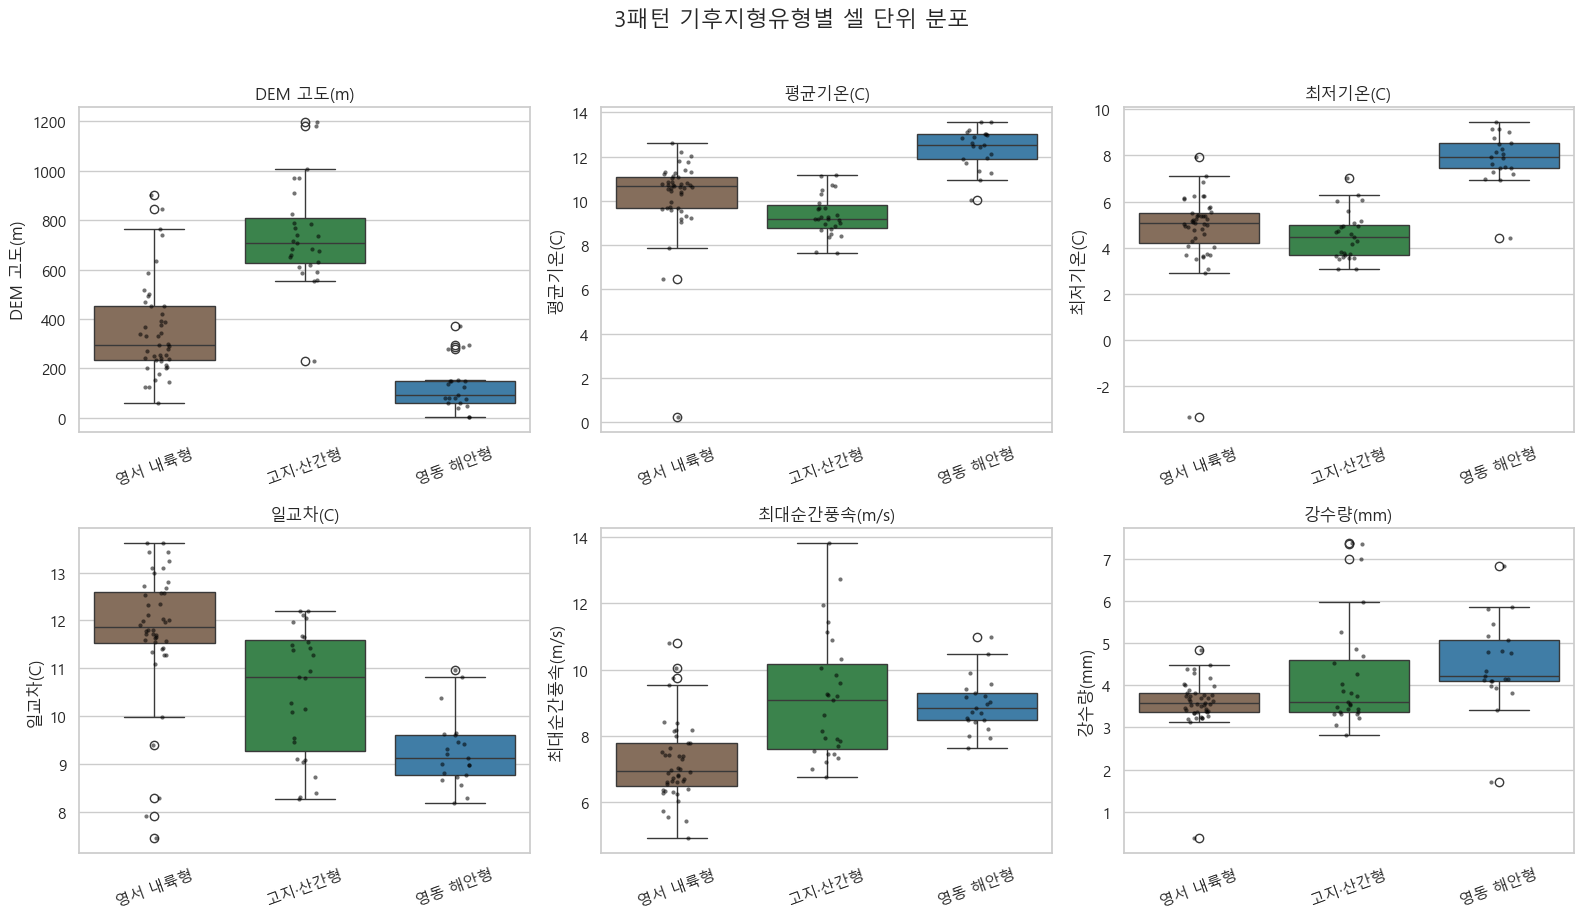

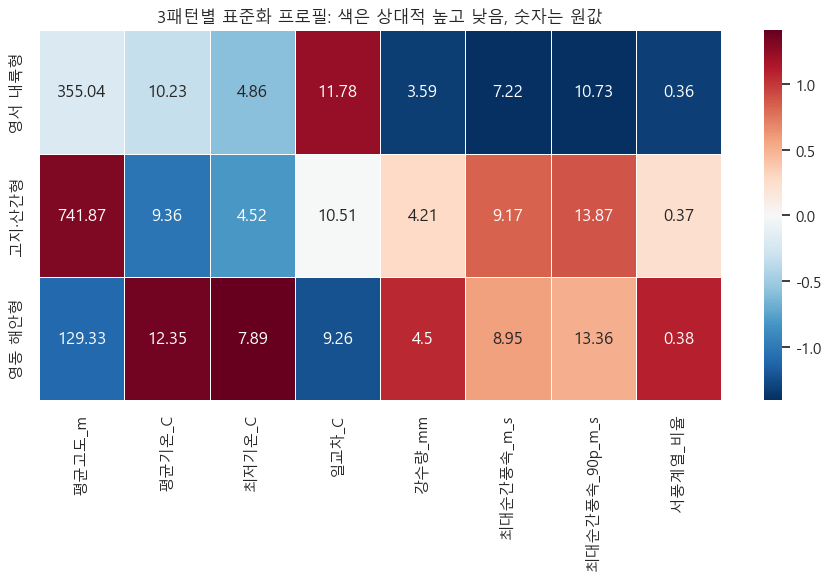

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
plot_specs = [
    ("elev_m", "DEM 고도(m)"),
    ("avg_temp", "평균기온(C)"),
    ("min_temp", "최저기온(C)"),
    ("daily_temp_range", "일교차(C)"),
    ("max_gust", "최대순간풍속(m/s)"),
    ("precip", "강수량(mm)"),
]
for ax, (var, label) in zip(axes.ravel(), plot_specs):
    sns.boxplot(data=three_cell, x="climate_terrain_type", y=var, order=TYPE_ORDER, hue="climate_terrain_type", palette=TYPE_PALETTE, legend=False, ax=ax)
    sns.stripplot(data=three_cell, x="climate_terrain_type", y=var, order=TYPE_ORDER, color="black", size=3, alpha=0.55, ax=ax)
    ax.set_title(label)
    ax.set_xlabel("")
    ax.set_ylabel(label)
    ax.tick_params(axis="x", rotation=20)
fig.suptitle("3패턴 기후지형유형별 셀 단위 분포", fontsize=16, y=1.02)
fig.tight_layout()
plt.show()

profile_vars = ["평균고도_m", "평균기온_C", "최저기온_C", "일교차_C", "강수량_mm", "최대순간풍속_m_s", "최대순간풍속_90p_m_s", "서풍계열_비율"]
prof = three_profile[profile_vars].copy()
z = (prof - prof.mean(axis=0)) / prof.std(axis=0, ddof=0)
fig, ax = plt.subplots(figsize=(11, 4.8))
sns.heatmap(z, cmap="RdBu_r", center=0, annot=prof.round(2), fmt="", linewidths=0.5, ax=ax)
ax.set_title("3패턴별 표준화 프로필: 색은 상대적 높고 낮음, 숫자는 원값")
ax.set_xlabel("")
ax.set_ylabel("")
plt.show()

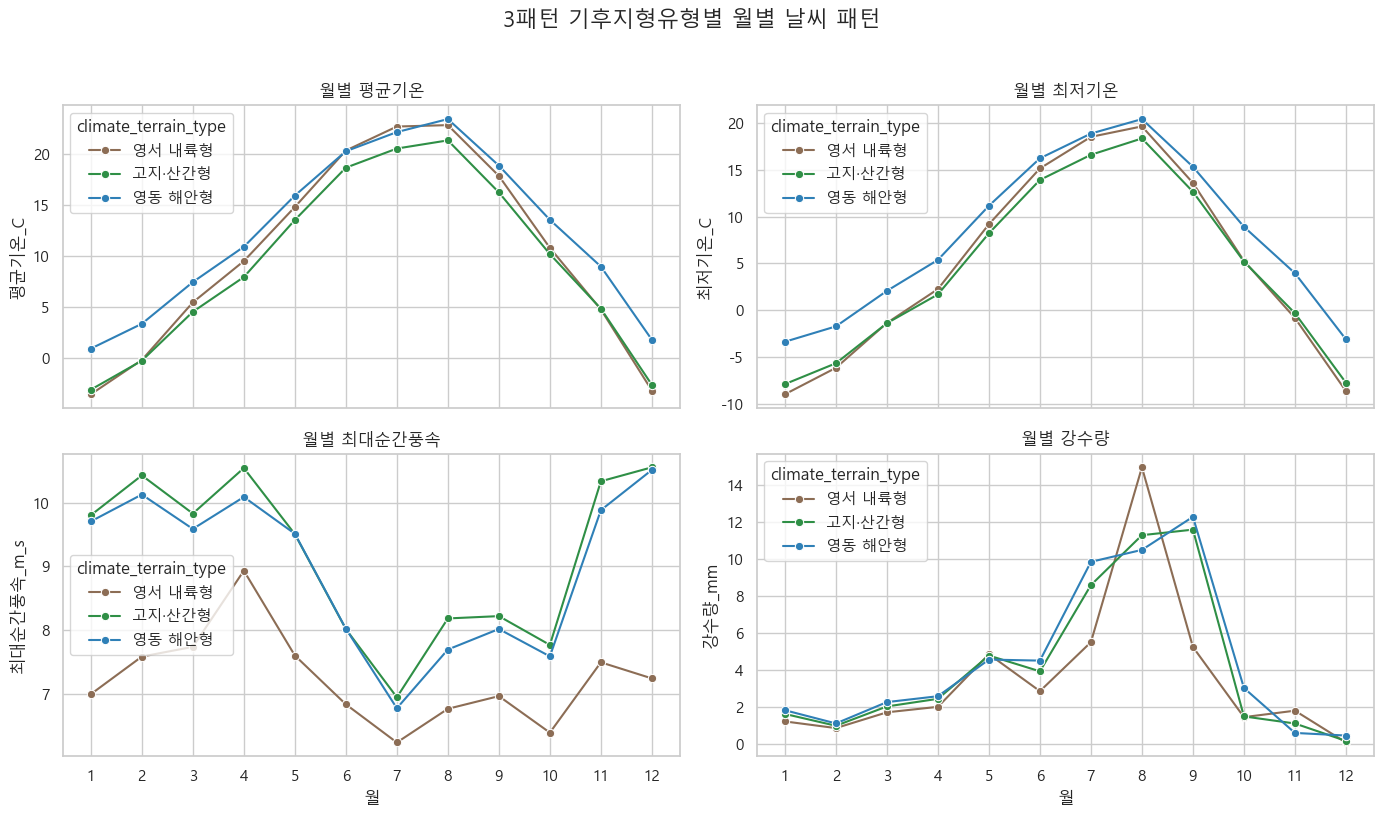

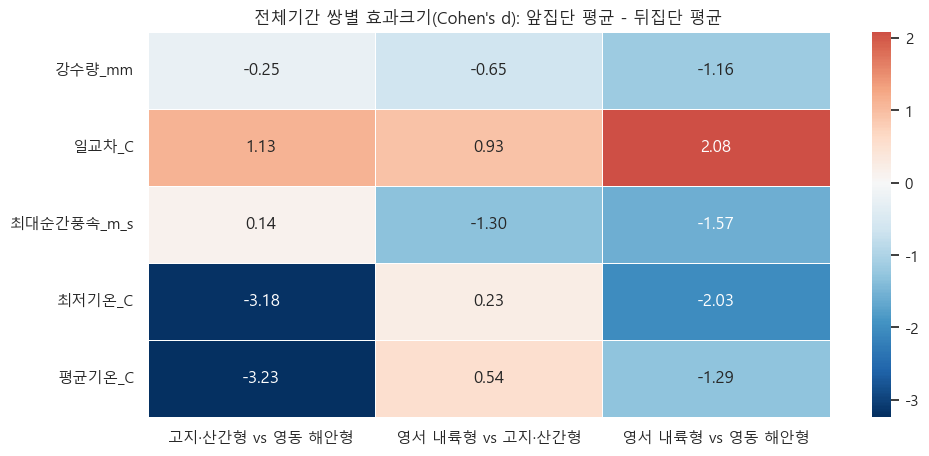

In [16]:
three_month = (
    three_df.groupby(["month", "climate_terrain_type"], as_index=False)
    .agg(
        평균기온_C=("avg_temp", "mean"),
        최저기온_C=("min_temp", "mean"),
        일교차_C=("daily_temp_range", "mean"),
        강수량_mm=("precip", "mean"),
        최대순간풍속_m_s=("max_gust", "mean"),
    )
)

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
for ax, var, title in zip(
    axes.ravel(),
    ["평균기온_C", "최저기온_C", "최대순간풍속_m_s", "강수량_mm"],
    ["월별 평균기온", "월별 최저기온", "월별 최대순간풍속", "월별 강수량"],
):
    sns.lineplot(data=three_month, x="month", y=var, hue="climate_terrain_type", hue_order=TYPE_ORDER, palette=TYPE_PALETTE, marker="o", ax=ax)
    ax.set_title(title)
    ax.set_xlabel("월")
    ax.set_ylabel(var)
    ax.set_xticks(range(1, 13))
fig.suptitle("3패턴 기후지형유형별 월별 날씨 패턴", fontsize=16, y=1.02)
fig.tight_layout()
plt.show()

effect_pair = pairwise_3pattern[
    (pairwise_3pattern["분석범위"] == "전체기간")
    & (pairwise_3pattern["변수"].isin(["평균기온_C", "최저기온_C", "일교차_C", "최대순간풍속_m_s", "강수량_mm"]))
]
effect_pivot = effect_pair.pivot(index="변수", columns="비교", values="Cohen_d")
fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(effect_pivot, cmap="RdBu_r", center=0, annot=True, fmt=".2f", linewidths=0.5, ax=ax)
ax.set_title("전체기간 쌍별 효과크기(Cohen's d): 앞집단 평균 - 뒤집단 평균")
ax.set_xlabel("")
ax.set_ylabel("")
plt.show()

### 4번 EDA 결론: 3패턴 분류의 날씨·지형 정당성

- **고지·산간형은 지형적으로 분명히 다르다.** 평균 DEM 고도는 고지·산간형 741.9m, 영서 내륙형 355.0m, 영동 해안형 129.3m이다.
- **고지·산간형은 영서 내륙보다 더 차갑고 더 바람이 강한 산지축이다.** 전체기간 셀 평균 기준 고지·산간형의 평균기온은 9.36℃로 영서 내륙형 10.23℃보다 낮고, 최대순간풍속은 9.17m/s로 영서 내륙형 7.22m/s보다 높다. 최대순간풍속의 세 권역 차이는 Kruskal p=2.20e-08이고, 고지·산간형 vs 영서 내륙형 효과크기는 d=-1.30이다.
- **영동 해안형은 따뜻하고 일교차가 작다.** 평균기온은 영동 해안형 12.35℃가 가장 높고, 일교차는 9.26℃로 가장 작다. 이 패턴은 해양 영향과 기존 영동권 유지 기준을 뒷받침한다.
- **3패턴 간 차이는 풍향보다 기온·고도·일교차·풍속에서 강하다.** 평균기온, 최저기온, 최고기온, 일교차, 강수량, 최대순간풍속은 세 권역 차이가 유의하지만, 서풍계열 비율은 유의하지 않다. 따라서 이 분류의 핵심 근거는 `풍향 자체`가 아니라 `연속 산지축 + 저온 + 강풍 + 해안 온난성`이다.
- 결론적으로 이 3패턴은 군집분석만으로 만든 임의 분류가 아니라, **기존 영동 보존 + 연속 산지축 분리 + 날씨 차이 검정**으로 정당화되는 분석용 기후지형유형이다.